In [1]:
# In [1]:
# TF1-style code from the course:
#     from keras.backend.tensorflow_backend import set_session
#     config = tf.ConfigProto(); config.gpu_options.allow_growth = True
#     config.log_device_placement = True
#     sess = tf.Session(config=config); set_session(sess)
# ConfigProto / Session / set_session were all removed in TF 2.x — eager
# execution is the default and there is no session to configure.
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

# ---------------------------------------------------------------------------
# THIS NOTEBOOK TRAINS ON THE CPU. That is deliberate — see below.
#
# The relu model here is an 8-layer stack of 700-unit Dense layers. Trained on
# the Apple Metal GPU (tensorflow-metal 1.2.0) it diverges to inf/NaN every
# time, while the identical code on the CPU converges to ~0.12 loss / 96.6%
# accuracy, which is what the lecture shows. Measured over 20 epochs, batch 256:
#
#   device / setting                  final loss    accuracy
#   CPU, course settings                  0.117       96.6%   <- matches lecture
#   GPU, course settings (lr=0.01)          nan        0.0%
#   GPU + clipnorm=1.0                    233.5       18.5%
#   GPU, lr=0.005                     5.29 / 0.34   coin flip
#   GPU, lr=0.002                         0.385       89.1%   (under-trained)
#   GPU, lr=0.001                         0.488       86.4%   (under-trained)
#
# Lowering the learning rate is the only thing that keeps the GPU stable, and
# it under-trains — and it would mean using a different lr for relu than for
# sigmoid/elu, which breaks the very comparison this notebook is about.
# The CPU costs ~95s per model instead of ~60s, so the whole notebook is only
# about 90s slower. Correct beats fast here.
#
# This is specific to this deep, wide, plain-relu stack. The GPU is fine for
# the convolutional notebooks later in the course — notebook 3 trains on it.
# To try the GPU anyway, comment out the next line.
# ---------------------------------------------------------------------------
tf.config.set_visible_devices([], "GPU")

print("Training on:", tf.config.get_visible_devices())

TensorFlow: 2.19.1
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Training on: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
# In [2]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import to_categorical
from keras.callbacks import Callback
from keras.datasets import mnist
import numpy as np

In [3]:
# In [3]:
(X_train_, y_train_), (X_test_, y_test_) = mnist.load_data()

In [4]:
# In [4]:
# Normalize data
X_train = X_train_.astype('float32') / 255.
X_test = X_test_.astype('float32') / 255.

In [5]:
# In [5]:
# One hot encoding labels
y_train = to_categorical(y_train_, 10)
y_test = to_categorical(y_test_, 10)

In [6]:
# In [6]:
# Flatten data
X_train = np.reshape(X_train, (60000, 784))
X_test = np.reshape(X_test, (10000, 784))

In [7]:
# In [7]:
import keras

# The course records logs['loss'] inside on_batch_end to get a per-batch loss curve.
# That worked in Keras 1, but in Keras 3 the value in the batch logs is the *running
# mean over the epoch so far* (it resets each epoch), which would draw 20 decaying
# sawtooth segments instead of the noisy per-batch trace the lecture shows.
# This tiny metric overwrites its value every batch instead of averaging, so it
# reports the true loss of the batch just processed.
class BatchLoss(keras.metrics.Metric):
    def __init__(self, name="batch_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.value = self.add_variable(shape=(), initializer="zeros", name="value")

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.value.assign(keras.ops.mean(
            keras.losses.categorical_crossentropy(y_true, y_pred)))

    def result(self):
        return self.value

    def reset_state(self):
        self.value.assign(0.0)

In [8]:
# In [ ]:
nn_sigmoid = Sequential()
# Keras 3: declare the input shape with an Input layer (input_dim= is deprecated)
nn_sigmoid.add(Input(shape=(784,)))
nn_sigmoid.add(Dense(700, activation='sigmoid'))
nn_sigmoid.add(Dense(700, activation='sigmoid'))
nn_sigmoid.add(Dense(700, activation='sigmoid'))
nn_sigmoid.add(Dense(700, activation='sigmoid'))
nn_sigmoid.add(Dense(350, activation='sigmoid'))
nn_sigmoid.add(Dense(100, activation='sigmoid'))
nn_sigmoid.add(Dense(10, activation='softmax'))

In [9]:
# Compile model with SGD
nn_sigmoid.compile(loss='categorical_crossentropy', optimizer='sgd',
                   metrics=['accuracy', BatchLoss()])

In [10]:
# In [9]:
nn_relu = Sequential()
# Keras 3: declare the input shape with an Input layer (input_dim= is deprecated)
nn_relu.add(Input(shape=(784,)))
nn_relu.add(Dense(700, activation='relu'))
nn_relu.add(Dense(700, activation='relu'))
nn_relu.add(Dense(700, activation='relu'))
nn_relu.add(Dense(700, activation='relu'))
nn_relu.add(Dense(700, activation='relu'))
nn_relu.add(Dense(350, activation='relu'))
nn_relu.add(Dense(100, activation='relu'))
nn_relu.add(Dense(10, activation='softmax'))

In [11]:
# Compile model with SGD
nn_relu.compile(loss='categorical_crossentropy', optimizer='sgd',
                metrics=['accuracy', BatchLoss()])

In [12]:
# In [11]:
nn_elu = Sequential()
# Keras 3: declare the input shape with an Input layer (input_dim= is deprecated)
nn_elu.add(Input(shape=(784,)))
nn_elu.add(Dense(700, activation='elu'))
nn_elu.add(Dense(700, activation='elu'))
nn_elu.add(Dense(700, activation='elu'))
nn_elu.add(Dense(700, activation='elu'))
nn_elu.add(Dense(700, activation='elu'))
nn_elu.add(Dense(350, activation='elu'))
nn_elu.add(Dense(100, activation='elu'))
nn_elu.add(Dense(10, activation='softmax'))

In [13]:
# Compile model with SGD
nn_elu.compile(loss='categorical_crossentropy', optimizer='sgd',
               metrics=['accuracy', BatchLoss()])

In [14]:
class history_loss(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        # logs['loss'] is the epoch running mean in Keras 3 -- use our per-batch metric
        self.losses.append(logs.get('batch_loss'))

In [15]:
# In [14]:
n_epochs = 20
batch_size = 256
validation_split = 0.2

In [16]:
# In [16]:
history_sigmoid = history_loss()
# verbose=2 -> one line per epoch. verbose=1 gives a live per-batch bar, but it
# emits ~3800 redraws per model, which is very slow when the notebook is run
# headlessly (jupyter nbconvert --execute). Switch to 1 for interactive runs.
nn_sigmoid.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
               callbacks=[history_sigmoid], validation_split=validation_split, verbose=2)

Epoch 1/20
188/188 - 2s - 13ms/step - accuracy: 0.1110 - batch_loss: 2.3013 - loss: 2.3129 - val_accuracy: 0.1060 - val_batch_loss: 2.3013 - val_loss: 2.3020
Epoch 2/20
188/188 - 3s - 14ms/step - accuracy: 0.1140 - batch_loss: 2.3014 - loss: 2.3014 - val_accuracy: 0.1060 - val_batch_loss: 2.3014 - val_loss: 2.3026
Epoch 3/20
188/188 - 3s - 14ms/step - accuracy: 0.1140 - batch_loss: 2.3022 - loss: 2.3015 - val_accuracy: 0.1060 - val_batch_loss: 2.3022 - val_loss: 2.3024
Epoch 4/20
188/188 - 3s - 14ms/step - accuracy: 0.1140 - batch_loss: 2.3012 - loss: 2.3014 - val_accuracy: 0.1060 - val_batch_loss: 2.3012 - val_loss: 2.3025
Epoch 5/20
188/188 - 3s - 15ms/step - accuracy: 0.1140 - batch_loss: 2.3020 - loss: 2.3013 - val_accuracy: 0.1060 - val_batch_loss: 2.3020 - val_loss: 2.3019
Epoch 6/20
188/188 - 3s - 14ms/step - accuracy: 0.1140 - batch_loss: 2.3015 - loss: 2.3013 - val_accuracy: 0.1060 - val_batch_loss: 2.3015 - val_loss: 2.3022
Epoch 7/20
188/188 - 3s - 15ms/step - accuracy: 0.11

In [17]:
# In [17]:
history_relu = history_loss()
# verbose=2 -> one line per epoch. verbose=1 gives a live per-batch bar, but it
# emits ~3800 redraws per model, which is very slow when the notebook is run
# headlessly (jupyter nbconvert --execute). Switch to 1 for interactive runs.
nn_relu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
            callbacks=[history_relu], validation_split=validation_split, verbose=2)

Epoch 1/20
188/188 - 3s - 18ms/step - accuracy: 0.4605 - batch_loss: 1.9088 - loss: 2.1788 - val_accuracy: 0.6494 - val_batch_loss: 1.9088 - val_loss: 1.9117
Epoch 2/20
188/188 - 3s - 16ms/step - accuracy: 0.7497 - batch_loss: 0.5079 - loss: 1.1719 - val_accuracy: 0.8428 - val_batch_loss: 0.5079 - val_loss: 0.6049
Epoch 3/20
188/188 - 3s - 18ms/step - accuracy: 0.8533 - batch_loss: 0.6244 - loss: 0.5110 - val_accuracy: 0.7283 - val_batch_loss: 0.6244 - val_loss: 0.8424
Epoch 4/20
188/188 - 3s - 18ms/step - accuracy: 0.8898 - batch_loss: 0.2139 - loss: 0.3837 - val_accuracy: 0.9043 - val_batch_loss: 0.2139 - val_loss: 0.3273
Epoch 5/20
188/188 - 4s - 19ms/step - accuracy: 0.9064 - batch_loss: 0.2087 - loss: 0.3227 - val_accuracy: 0.9088 - val_batch_loss: 0.2087 - val_loss: 0.3044
Epoch 6/20
188/188 - 3s - 18ms/step - accuracy: 0.9175 - batch_loss: 0.2174 - loss: 0.2866 - val_accuracy: 0.9163 - val_batch_loss: 0.2174 - val_loss: 0.2789
Epoch 7/20
188/188 - 4s - 19ms/step - accuracy: 0.92

In [18]:
# In [18]:
history_elu = history_loss()
# verbose=2 -> one line per epoch. verbose=1 gives a live per-batch bar, but it
# emits ~3800 redraws per model, which is very slow when the notebook is run
# headlessly (jupyter nbconvert --execute). Switch to 1 for interactive runs.
nn_elu.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size,
           callbacks=[history_elu], validation_split=validation_split, verbose=2)

Epoch 1/20
188/188 - 5s - 24ms/step - accuracy: 0.7939 - batch_loss: 0.3092 - loss: 0.8248 - val_accuracy: 0.8893 - val_batch_loss: 0.3092 - val_loss: 0.4206
Epoch 2/20
188/188 - 5s - 24ms/step - accuracy: 0.8916 - batch_loss: 0.2336 - loss: 0.3904 - val_accuracy: 0.9072 - val_batch_loss: 0.2336 - val_loss: 0.3308
Epoch 3/20


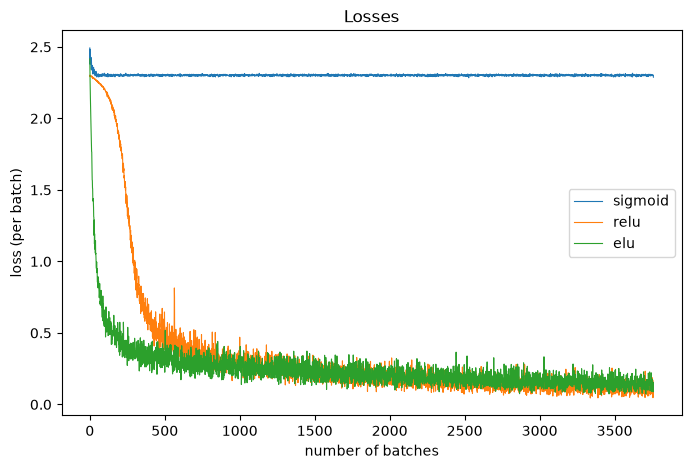

In [19]:
# In [19]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(history_sigmoid.losses)), history_sigmoid.losses, label='sigmoid', lw=0.8)
plt.plot(np.arange(len(history_relu.losses)), history_relu.losses, label='relu', lw=0.8)
plt.plot(np.arange(len(history_elu.losses)), history_elu.losses, label='elu', lw=0.8)
plt.title('Losses')
plt.xlabel('number of batches')
plt.ylabel('loss (per batch)')
plt.legend(loc='best')
plt.show()